In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import time

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#cluster to eq supertype mapping
#Oxt = ['2379 PVH-SO-PVa Otp Glut_4', '2381 PVH-SO-PVa Otp Glut_4']
#Avp = ['2380 PVH-SO-PVa Otp Glut_4']
#Ucn3 = ['2386 PVH-SO-PVa Otp Glut_6', '2385 PVH-SO-PVa Otp Glut_6']
#Trh = ['2375 PVH-SO-PVa Otp Glut_3']
#Crh = ['2378 PVH-SO-PVa Otp Glut_3', '2376 PVH-SO-PVa Otp Glut_3', '2377 PVH-SO-PVa Otp Glut_3']
#Sst = ['2382 PVH-SO-PVa Otp Glut_5', '2383 PVH-SO-PVa Otp Glut_5', '2384 PVH-SO-PVa Otp Glut_5']
#Nkx2-2 = ['2365 PVH-SO-PVa Otp Glut_1', '2374 PVH-SO-PVa Otp Glut_2', '2369 PVH-SO-PVa Otp Glut_2', '2373 PVH-SO-PVa Otp Glut_2', '2371 PVH-SO-PVa Otp Glut_2', '2366 PVH-SO-PVa Otp Glut_1', '2364 PVH-SO-PVa Otp Glut_1', '2370 PVH-SO-PVa Otp Glut_2', '2368 PVH-SO-PVa Otp Glut_1', '2372 PVH-SO-PVa Otp Glut_2', '2367 PVH-SO-PVa Otp Glut_1']

In [2]:
Allen_labs = pd.read_csv('../../Subclustering/PVH/Allen_labels_PVH_withcluster_09092026.csv',index_col='Unnamed: 0')

In [3]:
fn = '../../Subclustering/PVH/SAM_CJ'

sam = SAM()
sam.load_data(fn)

In [4]:
sam_test = SAM()
sam_test.load_data('../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_03122025.h5ad')

In [5]:
sam_test.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2',
       'test', 'ss_subclass_threshold_90', 'yanay_labels',
       'yanay_label_nounlabeled'],
      dtype='object')

In [6]:
tester = sam_test.adata[sam_test.adata.obs['ss_subclass_nounlabeled_03102026'] == '133 PVH-SO-PVa Otp Glut']

In [7]:
tester.X

<1309x19307 sparse matrix of type '<class 'numpy.float32'>'
	with 1862177 stored elements in Compressed Sparse Row format>

In [8]:
sam.adata.X

<1309x19307 sparse matrix of type '<class 'numpy.float32'>'
	with 1862177 stored elements in Compressed Sparse Row format>

In [9]:
def csr_equal(A, B):
    if A.shape != B.shape:
        return False
    return (A != B).nnz == 0

In [10]:
csr_equal(tester.X,sam.adata.X)

True

In [11]:
sam.clustering(param = 2)

In [12]:
fn_sm = '../../Subclustering/PVH/sm_Allen_mo_PVH_090820206.pkl'
sm = load_samap(fn_sm)

In [13]:
sm.sams['mg'].adata.obs['eq_supertype'] = Allen_labs['eq_supertype']

In [14]:
sm.sams['mg'].adata.obs.columns

Index(['Unnamed: 0', 'cell_label', 'cell_barcode',
       'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label',
       'entity', 'brain_section_label', 'library_method',
       'region_of_interest_acronym', 'donor_label', 'donor_genotype',
       'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias',
       'subclass_id_label', 'supertype_id_label', 'class_id_label',
       'leiden_clusters', 'eq_supertype'],
      dtype='object')

In [15]:
org_two = 'mo'

In [16]:
csr_equal(sm.sams[org_two].adata.X,sam.adata.X)

True

In [17]:
sm.sams[org_two].clustering(param = 2)

In [18]:
keys = {'mg':'eq_supertype',org_two:'leiden_clusters'}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable = MappingTable.filter(like='mg_')
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]

In [19]:
lim_MappingTable

,mg_Avp,mg_Crh,mg_Nkx2-2,mg_Oxt,mg_Sst,mg_Trh,mg_Ucn3
mo_0,0.817152,0.001315,0.000000,0.194070,0.000000,0.000000,0.000000
mo_1,0.007219,0.000172,0.000000,0.864979,0.009066,0.000000,0.000223
mo_10,0.000000,0.000200,0.876285,0.000981,0.001507,0.000000,0.007540
mo_11,0.000006,0.000009,0.717801,0.004365,0.000068,0.000909,0.014476
mo_12,0.000000,0.105735,0.000000,0.000000,0.011264,0.786178,0.000000
mo_13,0.016975,0.401241,0.013051,0.000000,0.000084,0.059332,0.000000
mo_2,0.000235,0.000358,0.865635,0.000327,0.001869,0.000368,0.005868
mo_3,0.000542,0.805290,0.000000,0.000000,0.004286,0.004404,0.000068
mo_4,0.000204,0.000254,0.565387,0.000052,0.003780,0.004909,0.001578
mo_5,0.025527,0.000010,0.000000,0.788456,0.002648,0.000042,0.000234


In [20]:
fin_mapping = {}
for item in lim_MappingTable.index:
    bm = lim_MappingTable.loc[item,:].idxmax()
    if lim_MappingTable.loc[item,bm] > .2:
        fin_mapping[item] = bm
    else:
        fin_mapping[item] = item
        
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [21]:
sam.adata.obs['test'] = fin_labels

In [22]:
mg_genes = ['Avp','Oxt','Nkx2-2','Ucn3','Sst','Crh','Ucn','Trh',]
mo_genes = ['Avp','Oxt','Nkx2-2','UCN3','Sst','Crh','UCN','Trh',]
cj_genes = ['ENSCJPG00005007573','ENSCJPG00005007570','ENSCJPG00005006711','SST','CRH','UCN','TRH']
ac_genes = ['LOC134299523','LOC134299526','nkx2-2','ucn3','sst','crh','trh']
xt_genes = ['avp','oxt','nkx2-2','ucn3','sst.1','ENSXETG00000035344','UCN','trh']
dr_genes = ['avp','oxt','nkx2.2a','ucn3l','sst1.1','crhb','uts1','trh']

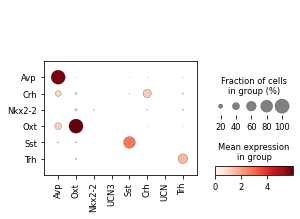

In [23]:
sc.pl.dotplot(sam.adata, groupby = 'test', var_names =mo_genes)

In [24]:
fin_mapping

{'mo_0': 'mg_Avp',
 'mo_1': 'mg_Oxt',
 'mo_10': 'mg_Nkx2-2',
 'mo_11': 'mg_Nkx2-2',
 'mo_12': 'mg_Trh',
 'mo_13': 'mg_Crh',
 'mo_2': 'mg_Nkx2-2',
 'mo_3': 'mg_Crh',
 'mo_4': 'mg_Nkx2-2',
 'mo_5': 'mg_Oxt',
 'mo_6': 'mg_Nkx2-2',
 'mo_7': 'mg_Sst',
 'mo_8': 'mg_Nkx2-2',
 'mo_9': 'mg_Nkx2-2'}

In [25]:
fin_labels = []
for item in sam.adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [26]:
sam.adata.obs['eq_supertype'] = fin_labels
sm.sams[org_two].adata.obs['eq_supertype'] = fin_labels

In [27]:
sm.sams[org_two].adata.obs['org_clusters'] = sam.adata.obs['leiden_clusters']
sam.adata.obs['org_clusters'] = sam.adata.obs['leiden_clusters']

In [28]:
sam.adata.obs['eq_supertype']

AAAGGGCAGTAGATCA       Avp
AACCTTTCAAAGACGC       Oxt
AAGCATCAGTGTTGAA    Nkx2-2
AAGTCGTGTCCTCAGG       Avp
ACAGAAAGTATGATCC       Sst
                     ...  
TTCGGTCCAGCTATTG       Avp
TTCGGTCCAGGCATTT       Oxt
TTGGGTACAGTTGGTT    Nkx2-2
TTGTTTGCACCGTGAC       Crh
TTTCAGTGTAAGGAGA       Oxt
Name: eq_supertype, Length: 1309, dtype: object

In [29]:
sam.save_anndata(fn)

In [30]:
save_samap(sm,fn_sm)